# Beginning - Calculate Electric Field Properties for a Step Index Fibre

We begin the project by calculating the electric field properties of the wave injected into the fibre. After that, we use the electric field profile to calculate the diffraction limited profile of the electric field. 

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi


## 1. Defind the fibre's core diameter and numerical aperature used for NIR

We will use a normalised frequency value provided from the approximated wavelength, fibre core radius and numerical aperature to "solve" the Bessel function which are defined to be proportional to the electric field as a function of radius, $E_{lm}(r)$. 

In [3]:
# wavelength of beam in vacuum
lam0 = 1.5e-6 
# fibre core radius
a = 5e-6 
# numerical aperture of fibre
NA = 0.1 

In [4]:
# Calculate the normalised frequency (V-number) of the fibre
V = 2 * pi * (a / lam0) * NA
print(f"V-number of the fibre: {V:.2f}")

V-number of the fibre: 2.09


In [5]:
# Approximate number of modes that the fibre can support using the V-number
M = V**2 / 4
print(f"Approximate number of modes that the fibre can support: {M:.2f}")

Approximate number of modes that the fibre can support: 1.10


## 2. Find the electric field profile by solving the characteristic equation computationally (or graphically)

Using the normalised frequency, we want to solve the characteristic equation (equivalent to the condition for a light wave propagating down a waveguide to remain in phase with itself). By solving the characteristic equation, we will drive the Bessel function used to represent the electric field inside the core and in the cladding. 

Characteristic equation: 
$X \frac{J_{l+1}(X)}{J_l(X)} = \pm Y \frac{K_{l+1}(Y)}{K_l(Y)}$

The relation: 
$X^2 + Y^2 = V^2 $

### Theory: Applying Bessel Functions here

For a step-index fibre, when we solve the wave equation in cylindrical coordinates, the radial part of the solution is no longer in the form of sine or cosine. 
Because we have approximated the electromagnetic field to be transverse as the light travelling down the fibre is close to the optical axis, and we have a weakly guiding fibre where the confinement of the field to the core is not strong. 

The field profile becomes:
 - Proportional to the ordinary Bessel function $J_l$ inside the fibre
 - Proportional to the modified Bessel function $K_l$ in the cladding

Note that we select X between 0 and V because:
$$
k_0 = \frac{2\pi}{\lambda}, \qquad
k_1 = n_1 k_0, \qquad
k_2 = n_2 k_0
$$

For a guided mode in a step-index fibre, the propagation constant must satisfy

$$
k_2 < \beta < k_1.
$$

This ensures that the field is oscillatory in the core and evanescent in the cladding. 
Using the definitions of $X$ and $Y$ introduced previously,

$$
X = a\sqrt{k_1^2 - \beta^2}, \qquad
Y = a\sqrt{\beta^2 - k_2^2},
$$

this condition guarantees that both $X$ and $Y$ are real, corresponding to a physically guided mode.

In [6]:
# jv?


For l=0, the characteristic equation becomes:

$X \frac{J_{1}(X)}{J_0(X)} = \pm Y \frac{K_{1}(Y)}{K_0(Y)}$

Find the root where $X \frac{J_{1}(X)}{J_0(X)} - Y \frac{K_{1}(Y)}{K_0(Y)} = 0$




In [7]:
# Define the range of x values for plotting the Bessel functions
X = np.linspace(0, V, 1000)
Y = np.sqrt(V**2 - X**2)

# Note: jv(v, z) represent first kind of Bessel function of order v and argument z is the input value, z = X * r / a 
LHS = X * jv(1, X) / jv(0, X)
RHS = Y * kv(1, Y) / kv(0, Y)



/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_85741/3346074594.py:7: RuntimeWarning: invalid value encountered in multiply
  RHS = Y * kv(1, Y) / kv(0, Y)


<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_85741/2814211851.py:3: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X, LHS, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_85741/2814211851.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X, RHS, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')


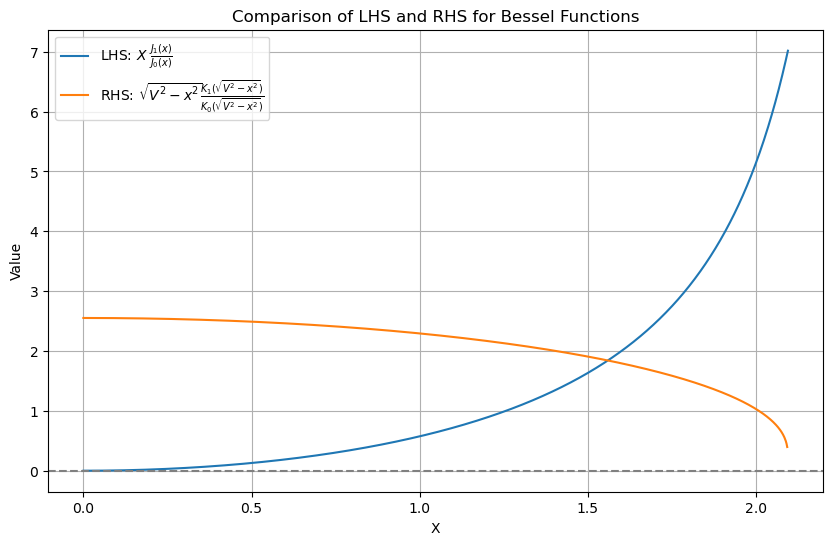

In [8]:
# Plot the left-hand side and right-hand side of the equation
plt.figure(figsize=(10, 6))
plt.plot(X, LHS, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X, RHS, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions')
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()

In [9]:
# Optional: difference function
diff = LHS - RHS

# --------------------------
# Find approximate intersection(s)
# --------------------------
roots = []
for i in range(len(X) - 1):
    if np.isfinite(diff[i]) and np.isfinite(diff[i+1]):
        # At X=0, LHS is smaller than RHS, so we look for sign changes in the product between the difference between LFH and RHS at consecutive points to find intersections
        if diff[i] * diff[i+1] < 0:
            roots.append((X[i] + X[i+1]) / 2)

print("Approximate intersections near X =", roots)

Approximate intersections near X = [np.float64(1.5587415001294707)]


In [10]:
from scipy.optimize import brentq
# The Brent's method is a root-finding algorithm that combines the bisection method, the secant method, and 
# inverse quadratic interpolation. 
# https://en.wikipedia.org/wiki/Brent%27s_method
# It is designed to find roots of a continuous function within a specified interval where the function changes
#  sign. The method is efficient and robust, making it suitable for finding roots of nonlinear equations.

def f(X, V):
    Y = np.sqrt(V**2 - X**2)
    lhs = X * jv(1, X) / jv(0, X)
    rhs = Y * kv(1, Y) / kv(0, Y)
    return lhs - rhs

# Define a lambda function that takes X as input and uses the previously defined function f with the 
# fixed V value. This allows us to use this function for root finding.
function_m1 = lambda X: f(X, V) 

# example bracket chosen after inspecting the plot
X_root = brentq(function_m1, 1.0, 2.0)
Y_root = np.sqrt(V**2 - X_root**2)

print("X root =", X_root)
print("Y root =", Y_root)

X root = 1.5590595758091075
Y root = 1.3985078062014993


In [11]:
# Quick test on focal ratio
focal_ratio = 1 / (2 * NA)
print(f"Focal ratio (f/#) corresponding to NA={NA}: {focal_ratio:.2f}")

# Approcimate angle Phi of the beam corresponding to NA 
#Na = n0 sin(Phi) where n0 is the refractive index of the medium (assumed to be 1 for air)
Phi = np.arcsin(NA / 1.0003)  # using n0 = 1.0003 for air
print(f"Approximate angle Phi of the beam corresponding to NA={NA}: {np.degrees(Phi):.2f} degrees")

Focal ratio (f/#) corresponding to NA=0.1: 5.00
Approximate angle Phi of the beam corresponding to NA=0.1: 5.74 degrees


Now since: 
$ X = k_T a$, 
$ Y = \gamma a$

We can model the electric field profile as a (normalised) function of the Bessel Functions: 

$$
E_{lm}(r) \propto 
\begin{cases}
J_l(k_{T_m} r), & r \le a \\
K_l(\gamma_m r), & r > a
\end{cases}
$$


$$
E_{lm}(r) \propto 
\begin{cases}
J_l(\frac{Xr}{a}), & r \le a \\
K_l(\frac{Yr}{a}), & r > a
\end{cases}
$$

Let $\rho = r/a$ be the normalised, so r/a≤1 is inside the core and r/a>1 is inside the cladding, r/a=0 is the fibre centre

$$
E(\rho)=
\begin{cases}
A\,J_0(X\rho), & \rho \le 1 \\
C\,K_0(Y\rho), & \rho > 1
\end{cases}
$$

At the core--cladding boundary, $\rho=1$, the field must be continuous, so

$$
A\,J_0(X)=C\,K_0(Y).
$$

Hence,

$$
C = A\,\frac{J_0(X)}{K_0(Y)}.
$$

Substituting this into the cladding solution gives

$$
E(\rho)=
\begin{cases}
A\,J_0(X\rho), & \rho \le 1 \\
A\,\dfrac{J_0(X)}{K_0(Y)}\,K_0(Y\rho), & \rho > 1.
\end{cases}
$$

Since we are only interested in the shape of the mode profile, we can choose the overall amplitude arbitrarily and set

$$
A=1.
$$

Therefore, the normalized field profile becomes

$$
E(\rho) =
\begin{cases}
J_0(X\rho), & \rho \le 1 \\
\dfrac{J_0(X)}{K_0(Y)} \, K_0(Y\rho), & \rho > 1
\end{cases}
$$

This piecewise expression represents the radial electric field profile of the fundamental mode in a step-index fibre, written in terms of the normalized radius $\rho = r/a$.

Inside the core ($\rho \le 1$), the solution is given by the ordinary Bessel function $J_0(X\rho)$, which describes an oscillatory field distribution. This arises from solving the wave equation in cylindrical coordinates where the field remains finite at the centre.

Outside the core ($\rho > 1$), the solution is given by the modified Bessel function $K_0(Y\rho)$, which decays exponentially. This represents the evanescent field in the cladding, where light is no longer propagating but instead decays away from the core.

The factor $\dfrac{J_0(X)}{K_0(Y)}$ ensures continuity of the electric field at the core–cladding boundary ($\rho = 1$). Without this scaling, the two solutions would not match at the boundary, leading to an unphysical discontinuity in the field.

In the code, this is implemented by:
- evaluating $J_0(X\rho)$ for $\rho \le 1$ (core region),
- evaluating $K_0(Y\rho)$ for $\rho > 1$ (cladding region),
- multiplying the cladding solution by the matching factor $\dfrac{J_0(X)}{K_0(Y)}$,
- combining both regions using boolean masks to construct the full piecewise field.

The resulting field is then normalized and squared to obtain the intensity profile.

In [12]:
# Step 1- Create the radius array for plotting the electric field distribution
rho = np.linspace(0, 3, 1000) # From 0 to 3 times the core radius

# Step 2 - Create an array of zeros with the same shape as rho to store the electric field values
E = np.zeros_like(rho)

# Step 3 - Set the condition as the boundary between core and cladding, this helps to create a piecewise function for the electric field distribution
core = rho <= 1
cladding = rho > 1

# Step 4 - Compute the electric field in the core region (rho <= 1) using the ordinary Bessel function J0.
# E[core] uses conditional (boolean) assignment directly: values are assigned only where the condition is satisfied, allowing us to implement the piecewise solution of the wave equation without using loops.
# Physically, this corresponds to applying the core solution E(rho) = J0(X*rho) only inside the fibre core.

E[core] = jv(0, X_root * rho[core]) # Setting A = 1, multiplied by te Bessel function of zeroth order and ratio rho inside the core

# Step 5 - Set the matching factor at the boundary (rho=1) as J0(X) / K0(Y), this makes the cladding field connect smoothly
match_factor = jv(0,X_root) / kv(0,Y_root) 

# Step 6 - Compute the electric field in the cladding region (rho > 1) using the modified Bessel function K0, multiplied by the matching factor to ensure continuity at the boundary
E[cladding] = match_factor * kv(0, Y_root * rho[cladding])

# Step 7 - Normalise the electric field distribution so that the maximum value is 1, this allows us to compare the relative field strength across the fibre cross-section
E_norm = E / np.max(abs(E)) 

# Step 8 - We also compute the intensity profile of the electric field, such that I represents the intensity profile and E represents the field amplitude. 
I = np.abs(E_norm)**2


If the field is not normalized, the solution retains an arbitrary amplitude factor A. 
While the functional form of the electric field is physically correct, its absolute magnitude is not defined 
by the wave equation alone and therefore does not correspond to a specific physical power. 

In this case, the electric field has units of V/m and the intensity has units of W/m², 
but their numerical values depend on the choice of A. 
Normalization is therefore typically applied when only the relative mode profile is of interest.

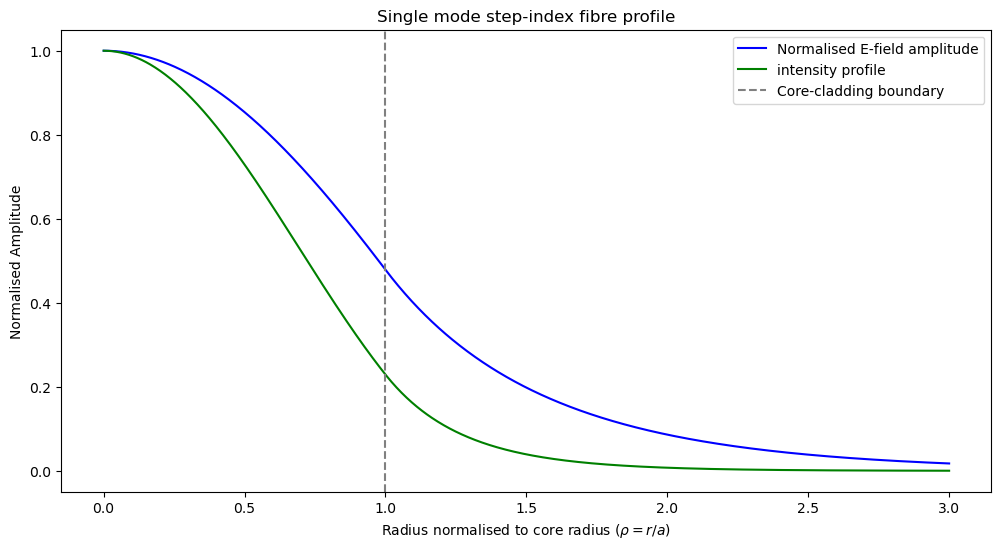

In [13]:
# Plot the normalised electric field distribution and the intensity profile
plt.figure(figsize=(12, 6))
plt.plot(rho, E_norm, label = 'Normalised E-field amplitude', color='blue')
plt.plot(rho, I, label = 'intensity profile', color='green')
plt.axvline(1, color = 'gray', linestyle='--', label='Core-cladding boundary')
plt.title("Single mode step-index fibre profile")
plt.xlabel('Radius normalised to core radius ($\\rho = r/a$)')
plt.ylabel('Normalised Amplitude')
plt.legend()
plt.show()

In [14]:
# match_factor.shape

In [15]:
# # Plot 3D intensity distribution across the fibre cross-section
# # Create a 2D grid of x and y coordinates
# x = np.linspace(-3, 3, 1000) * a  # from -3a to 3a
# y = np.linspace(-3, 3, 1000) * a
# X_grid, Y_grid = np.meshgrid(x, y)

# plt.figure(figsize=(8, 6))
# plt.contourf(X_grid, Y_grid, I.reshape(X_grid.shape), levels=50, cmap='viridis')
# plt.colorbar(label='Intensity')
# plt.title('Intensity Distribution Across Fibre Cross-section')
# plt.xlabel('x (m)')
# plt.ylabel('y (m)')
# plt.show()

In [16]:
E_norm.shape

(1000,)

In [17]:
np.max(abs(E)) 

np.float64(1.0)

In [36]:
E

array([1.        , 0.99999452, 0.99997808, 0.99995068, 0.99991232,
       0.99986301, 0.99980273, 0.9997315 , 0.99964931, 0.99955617,
       0.99945208, 0.99933704, 0.99921104, 0.9990741 , 0.99892622,
       0.99876739, 0.99859762, 0.99841692, 0.99822528, 0.99802271,
       0.99780922, 0.9975848 , 0.99734946, 0.9971032 , 0.99684604,
       0.99657796, 0.99629898, 0.9960091 , 0.99570833, 0.99539667,
       0.99507412, 0.99474069, 0.99439639, 0.99404123, 0.9936752 ,
       0.99329831, 0.99291058, 0.992512  , 0.99210259, 0.99168234,
       0.99125127, 0.99080939, 0.9903567 , 0.9898932 , 0.98941891,
       0.98893384, 0.98843799, 0.98793137, 0.98741398, 0.98688584,
       0.98634696, 0.98579735, 0.985237  , 0.98466594, 0.98408418,
       0.98349171, 0.98288855, 0.98227472, 0.98165022, 0.98101506,
       0.98036925, 0.9797128 , 0.97904573, 0.97836804, 0.97767975,
       0.97698086, 0.97627139, 0.97555135, 0.97482076, 0.97407962,
       0.97332794, 0.97256574, 0.97179303, 0.97100983, 0.97021

The fundamental mode of a single-mode fibre can be approximated by a Gaussian field profile. 
The electric field amplitude is given by a Gaussian function, and the intensity follows as its square.

$$
E_{\mathrm{SMF}}(r) = E_0 \exp\!\left(-\frac{r^2}{w^2}\right)
$$

$$
I(r) = |E(r)|^2 = I_0 \exp\!\left(-\frac{2r^2}{w^2}\right)
$$

The intensity falls to $1/e^2$ of its maximum at

$$
r = \pm w,
$$

which defines the mode radius (beam waist). 
The parameter $w$ represents the mode radius (beam waist), defined as the radial distance at which 
the intensity drops to $1/e^2$ of its maximum value. 

The mode field diameter (MFD) is therefore

$$
d_{\mathrm{SMF}} = 2w.
$$

For a single-mode step-index fibre, and when $1.2<V<2.4$, the mode waist can be approximated using the Marcuse relation as:

$$
\frac{w}{a} \approx 0.65 + \frac{1.619}{V^{3/2}} + \frac{2.879}{V^6},
$$

so that

$$
w \approx a\left(0.65 + \frac{1.619}{V^{3/2}} + \frac{2.879}{V^6}\right).
$$

In [18]:
# The beam waist (w) is a measure of the width of the beam at its narrowest point, where the electric field amplitude drops to 1/e of its maximum value. 
# For our single mode fibre with 1.2<V<2.405, the beam waist can be approximated as w = a * (0.65 + 1.619 / V**(3/2) + 2.879 / V**6), where a is the core 
# radius and V is the normalised frequency of the fibre.

w = a * (0.65 + 1.619 / V**1.5 + 2.879 / V**6)

#Output electric field approximation for Gaussian beam
E_smf = np.exp(-(rho * a / w)**2)

# Output intensity profile for Gaussian beam
I_smf = np.abs(E_smf)**2

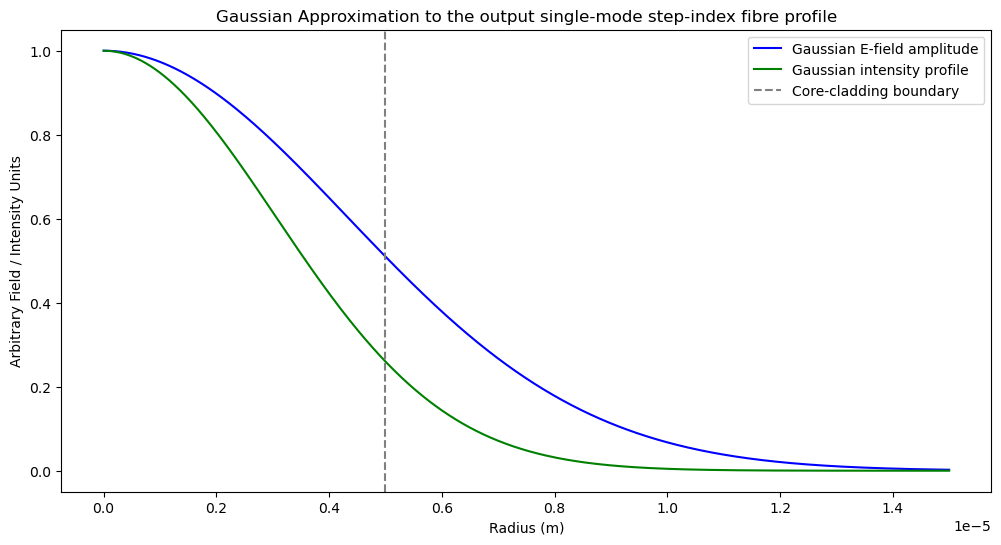

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(rho * a, E_smf, label='Gaussian E-field amplitude', color='blue')
plt.plot(rho * a, I_smf, label='Gaussian intensity profile', color='green')
plt.axvline(a, color='gray', linestyle='--', label='Core-cladding boundary')
plt.title('Gaussian Approximation to the output single-mode step-index fibre profile')
plt.xlabel(r'Radius (m)')
plt.ylabel('Arbitrary Field / Intensity Units')
plt.legend()
# plt.grid(True)
plt.show()

In [20]:
# Create a 2D grid in physical coordinates
x = np.linspace(-3, 3, 1000) * a
y = np.linspace(-3, 3, 1000) * a
X_grid, Y_grid = np.meshgrid(x, y)

# Normalized radial coordinate
rho_2d = np.sqrt(X_grid**2 + Y_grid**2) / a

# Empty 2D field array
E_2d = np.zeros_like(rho_2d)

# Core and cladding masks
core = rho_2d <= 1
cladding = rho_2d > 1

# Core field
E_2d[core] = jv(0, X_root * rho_2d[core])

# Matching factor for continuity at rho = 1
match_factor = jv(0, X_root) / kv(0, Y_root)

# Cladding field
E_2d[cladding] = match_factor * kv(0, Y_root * rho_2d[cladding])

# Normalize field if desired
E_2d_norm = E_2d / np.max(np.abs(E_2d))

# Intensity
I_2d = np.abs(E_2d_norm)**2



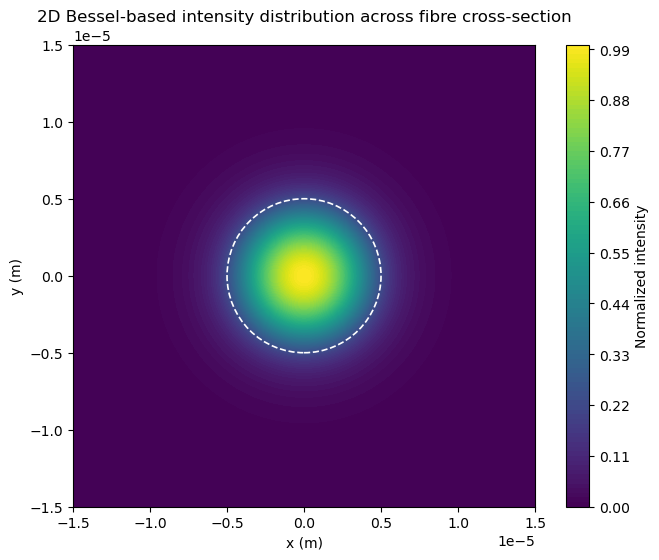

In [21]:
# Plot contour
plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, I_2d, levels=100, cmap='viridis')
plt.colorbar(label='Normalized intensity')
plt.title('2D Bessel-based intensity distribution across fibre cross-section')
circle = plt.Circle((0, 0), a, color='white', fill=False, linestyle='--', linewidth=1.2)
plt.gca().add_patch(circle)

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.gca().set_aspect('equal')

plt.show()

In [22]:
a

5e-06

## Increasing the number of modes

### 2 modes

In [23]:
# Quick test: how big would the a need to be to support m=2, m=3 modes?
# V = 2 * pi * (a / lam0) * NA
# a = V * lam0 / (2 * pi * NA)
# M = V^2 / 4

# M=2
V_m2 = np.sqrt(4*2)
a_m2 = V_m2 * lam0 / (2 * np.pi * NA)



print(f"To support M=2 modes, the core radius a needs to be at least {a_m2*1e6:.2f} microns")


To support M=2 modes, the core radius a needs to be at least 6.75 microns


In [24]:
print(f"Corresponding V-number for M=2 modes: {V_m2:.2f}" )


Corresponding V-number for M=2 modes: 2.83


In [25]:
# Define the range of x values for plotting the Bessel functions
X_m2 = np.linspace(0, V_m2, 1000)
Y_m2 = np.sqrt(V_m2**2 - X_m2**2)

# Note: jv(v, z) represent first kind of Bessel function of order v and argument z is the input value, z = X * r / a 
LHS_m2 = X_m2 * jv(1, X_m2) / jv(0, X_m2)
RHS_m2 = Y_m2 * kv(1, Y_m2) / kv(0, Y_m2)


/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_85741/759183413.py:7: RuntimeWarning: invalid value encountered in multiply
  RHS_m2 = Y_m2 * kv(1, Y_m2) / kv(0, Y_m2)


<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_85741/85276601.py:3: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X_m2, LHS_m2, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_85741/85276601.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m2, RHS_m2, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')


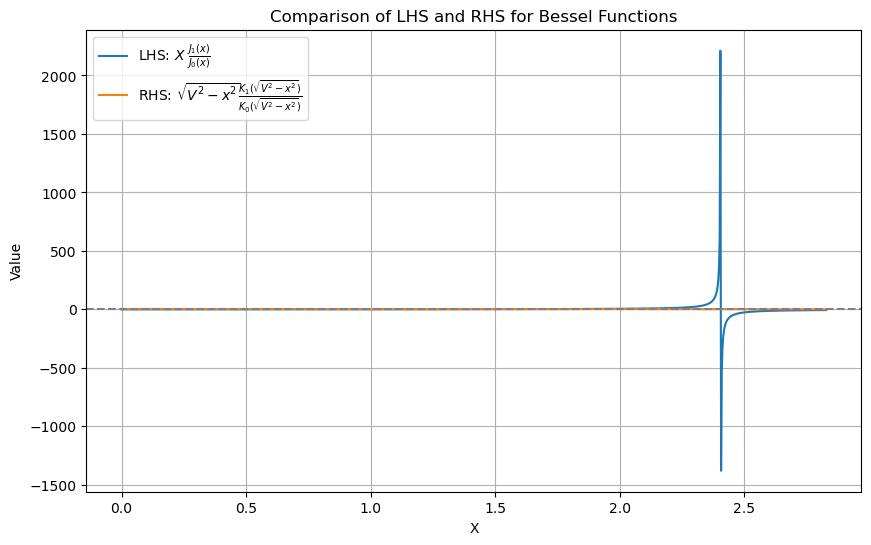

In [26]:
# Plot the left-hand side and right-hand side of the equation
plt.figure(figsize=(10, 6))
plt.plot(X_m2, LHS_m2, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X_m2, RHS_m2, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions')
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()

<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_85741/4053346443.py:3: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X_m2, LHS_m2, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_85741/4053346443.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m2, RHS_m2, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')


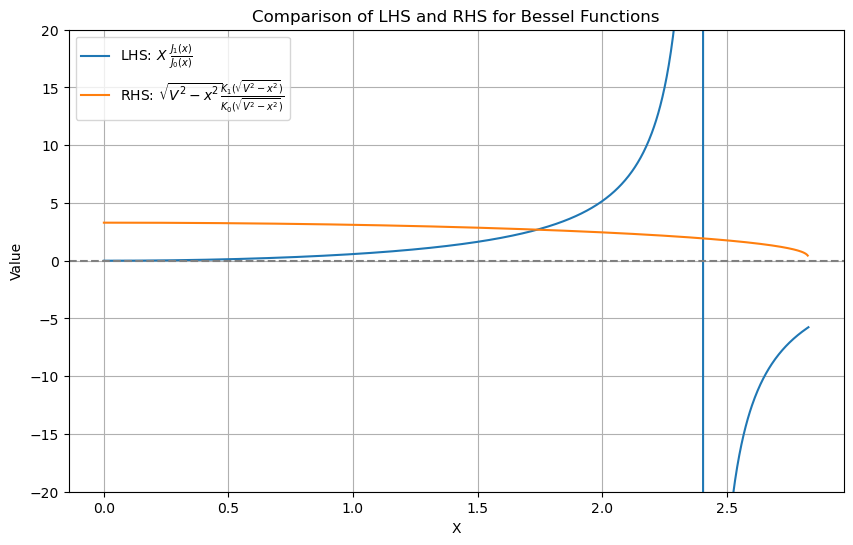

In [27]:
# Plot the left-hand side and right-hand side of the equation
plt.figure(figsize=(10, 6))
plt.plot(X_m2, LHS_m2, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X_m2, RHS_m2, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions')
plt.ylim(-20, 20)
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()

In [28]:
def calculate_electric_field(X_root, Y_root):
    """ 
    Define a function to calculate the electric field distribution across the fibre 
    cross-section based on the roots found from the Bessel function equations. This function 
    will compute the electric field in both the core and cladding regions, normalise it, and 
    return both the normalised electric field and its intensity profile. 

    X_root: The root of the equation for the core region, which determines the behaviour of the electric field within the core.
    Y_root: The root of the equation for the cladding region, which determines the behaviour of the electric field in the cladding.

    """
    

    # Step 1- Create the radius array for plotting the electric field distribution
    rho = np.linspace(0, 3, 1000) # From 0 to 3 times the core radius

    # Step 2 - Create an array of zeros with the same shape as rho to store the electric field values
    E = np.zeros_like(rho)

    # Step 3 - Set the condition as the boundary between core and cladding, this helps to create a piecewise function for the electric field distribution
    core = rho <= 1
    cladding = rho > 1

    # Step 4 - Compute the electric field in the core region (rho <= 1) using the ordinary Bessel function J0.
    # E[core] uses conditional (boolean) assignment directly: values are assigned only where the condition is satisfied, allowing us to implement the piecewise solution of the wave equation without using loops.
    # Physically, this corresponds to applying the core solution E(rho) = J0(X*rho) only inside the fibre core.

    E[core] = jv(0, X_root * rho[core]) # Setting A = 1, multiplied by te Bessel function of zeroth order and ratio rho inside the core

    # Step 5 - Set the matching factor at the boundary (rho=1) as J0(X) / K0(Y), this makes the cladding field connect smoothly
    match_factor = jv(0,X_root) / kv(0,Y_root) 

    # Step 6 - Compute the electric field in the cladding region (rho > 1) using the modified Bessel function K0, multiplied by the matching factor to ensure continuity at the boundary
    E[cladding] = match_factor * kv(0, Y_root * rho[cladding])

    # Step 7 - Normalise the electric field distribution so that the maximum value is 1, this allows us to compare the relative field strength across the fibre cross-section
    E_norm = E / np.max(abs(E)) 

    # Step 8 - We also compute the intensity profile of the electric field, such that I represents the intensity profile and E represents the field amplitude. 
    I = np.abs(E_norm)**2

    return E_norm, I

In [29]:
# Define a lambda function for the root finding of the second mode, using the same function f but with the new V_m2 value corresponding to M=2 modes
function_m2 = lambda X: f(X, V_m2)

# Find all roots by scanning for sign changes and refining with brentq
x_scan = np.linspace(1e-6, V_m2 - 1e-6, 5000)
f_scan = function_m2(x_scan)

roots_m2 = []
for i in range(len(x_scan) - 1):
    x0, x1 = x_scan[i], x_scan[i + 1]
    y0, y1 = f_scan[i], f_scan[i + 1]

    if not (np.isfinite(y0) and np.isfinite(y1)): # Skip intervals where the function is not finite to avoid errors in root finding 
        continue #continue means to skip the current iteration of the loop and move on to the next one, this is useful for handling cases where the function may have singularities or discontinuities that could cause issues with root finding algorithms like brentq.
    # Check for a sign change between y0 and y1, which indicates the presence of a root in the interval [x0, x1]. If a sign change is detected, we can use brentq to find the root more accurately within that interval.
    if y0 * y1 < 0:
        try:
            r = brentq(function_m2, x0, x1)
            if not any(np.isclose(r, rr, atol=1e-6) for rr in roots_m2):
                roots_m2.append(r)
        except ValueError:
            pass

roots_m2 = sorted(roots_m2)

if len(roots_m2) < 2:
    raise ValueError(f"Only found {len(roots_m2)} root(s) for V_m2={V_m2:.4f}; need at least two.")

X_root_m2_1 = roots_m2[0]
X_root_m2_2 = roots_m2[1]
Y_root_m2_1 = np.sqrt(V_m2**2 - X_root_m2_1**2)
Y_root_m2_2 = np.sqrt(V_m2**2 - X_root_m2_2**2)

# Keep compatibility with existing cells
X_root_m2 = X_root_m2_1
Y_root_m2 = Y_root_m2_1

print("All roots found =", roots_m2)
print("First root:  X =", X_root_m2_1, ", Y =", Y_root_m2_1)
print("Second root: X =", X_root_m2_2, ", Y =", Y_root_m2_2)

All roots found = [1.7397133910685814, 2.4048255576963253]
First root:  X = 1.7397133910685814 , Y = 2.2301115032519467
Second root: X = 2.4048255576963253 , Y = 1.488896919551706


In [30]:
E_norm_m2_1, I_m2_1 = calculate_electric_field(X_root_m2_1, Y_root_m2_1)
E_norm_m2_2, I_m2_2 = calculate_electric_field(X_root_m2_2, Y_root_m2_2)

# Keep compatibility with existing plotting cell below
# E_norm_m2, I_m2 = E_norm_m2_1, I_m2_1

E_norm_m2_tot = E_norm_m2_1 + E_norm_m2_2
I_m2_tot = np.abs(E_norm_m2_tot)**2

print("Computed electric fields for both first and second roots.")
E_norm_m2_1.shape, I_m2_1.shape, E_norm_m2_2.shape, I_m2_2.shape

Computed electric fields for both first and second roots.


((1000,), (1000,), (1000,), (1000,))

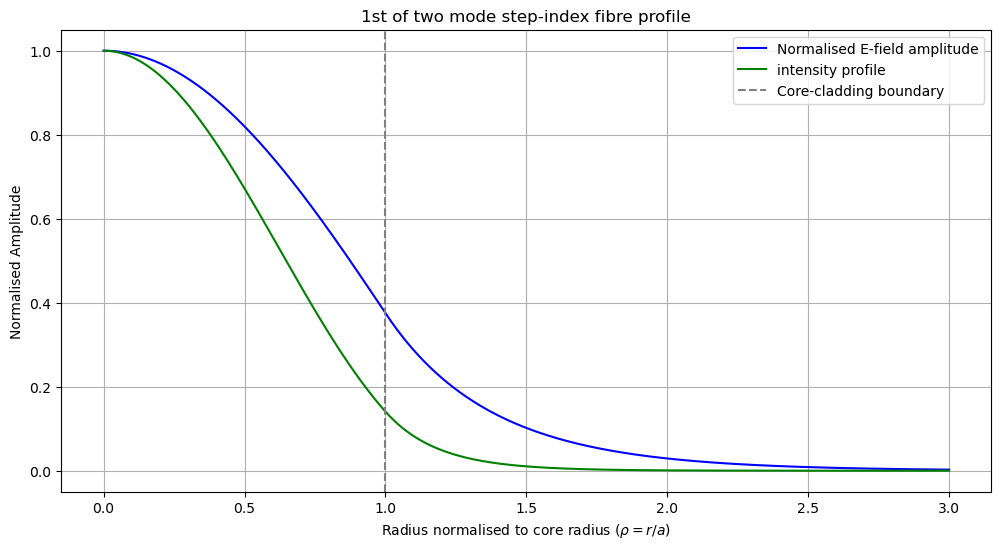

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(rho, E_norm_m2_1, label = 'Normalised E-field amplitude', color='blue')
plt.plot(rho, I_m2_1, label = 'intensity profile', color='green')
plt.axvline(1, color = 'gray', linestyle='--', label='Core-cladding boundary')
plt.title("1st of two mode step-index fibre profile")
plt.xlabel('Radius normalised to core radius ($\\rho = r/a$)')
plt.ylabel('Normalised Amplitude')
plt.legend()
plt.grid()
plt.show()

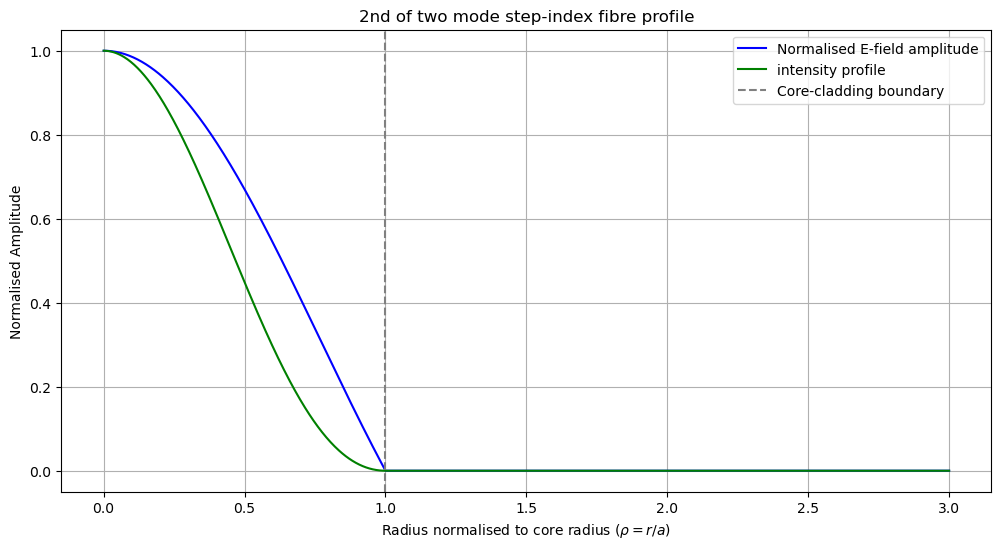

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(rho, E_norm_m2_2, label = 'Normalised E-field amplitude', color='blue')
plt.plot(rho, I_m2_2, label = 'intensity profile', color='green')
plt.axvline(1, color = 'gray', linestyle='--', label='Core-cladding boundary')
plt.title("2nd of two mode step-index fibre profile")
plt.xlabel('Radius normalised to core radius ($\\rho = r/a$)')
plt.ylabel('Normalised Amplitude')
plt.legend()
plt.grid()
plt.show()

### Corrected 2 modes, LP02 needs V > 3.8317

In [ ]:
# For LP02 mode to appear, the minimum V-number is 3.8317
V_lp02 = 3.9 # choose a normalised frequency above cutoff
a_lp02 = V_lp02 * lam0 / (2*np.pi*NA)
print(f"The core radius for LP02 mode to appear is at around: {a_lp02*1e6:.3f} μm")

The core radius for LP02 mode to appear is at around: 9.310564170875877e-06 μm


In [64]:
# Define a characteristic equation for l=0 specifically
def function_LP02(X, V): 
    Y = np.sqrt(V**2 - X**2)
    lhs = - X * jv(1, X) / jv(0, X)
    rhs = Y * kv(1, Y) / kv(0, Y)
    return lhs - rhs

In [65]:
# First zero of J0
X0 = 2.4048255577

# Search for the root corresponding to the LP02 mode
X_search_lp02 = np.linspace(X0 + 1e-4, V_lp02 - 1e-4, 5000)
F_search_lp02 = function_LP02(X_search_lp02, V_lp02)

bracket_lp02 = None

for i in range(len(X_search_lp02) - 1):
    x1 = X_search_lp02[i]
    x2 = X_search_lp02[i + 1]
    f1 = F_search_lp02[i]
    f2 = F_search_lp02[i + 1]

    if abs(jv(0, x1)) < 1e-8 or abs(jv(0, x2)) < 1e-8:
        continue

    if f1 * f2 < 0:
        bracket_lp02 = (x1, x2)
        break

if bracket_lp02 is None:
    raise ValueError("No root found for LP02 mode in the specified range.")
else:
    X_root_lp02 = brentq(function_LP02, bracket_lp02[0], bracket_lp02[1], args=(V_lp02,))
    Y_root_lp02 = np.sqrt(V_lp02**2 - X_root_lp02**2)
    print(f"Root for LP02 mode found at X = {X_root_lp02:.6f}, Y = {Y_root_lp02:.6f}")

print(f"V_lp02 = {V_lp02}")
print(f"LP02 candidate root: X = {X_root_lp02:.6f}, Y = {Y_root_lp02:.6f}")
print(f"Radial node at rho = {X0 / X_root_lp02:.4f}")

Root for LP02 mode found at X = 3.180640, Y = 2.256885
V_lp02 = 3.9
LP02 candidate root: X = 3.180640, Y = 2.256885
Radial node at rho = 0.7561


In [66]:
rho_02_1d = np.linspace(0, 3) # From 0 to 3 times the core radius
E_lp02_1d = np.zeros_like(rho_02_1d)
core_02 = rho_02_1d <= 1
cladding_02 = rho_02_1d > 1
E_lp02_1d[core_02] = jv(0, X_root_lp02 * rho_02_1d[core_02])
C = jv(0, X_root_lp02) / kv(0, Y_root_lp02) # Matching factor for continuity at rho = 1
E_lp02_1d[cladding_02] = C * kv(0, Y_root_lp02 * rho_02_1d[cladding_02])

# Normalise the electric field distribution
E_lp02_1d_norm = E_lp02_1d / np.max(np.abs(E_lp02_1d))
I_lp02_1d = np.abs(E_lp02_1d_norm)**2

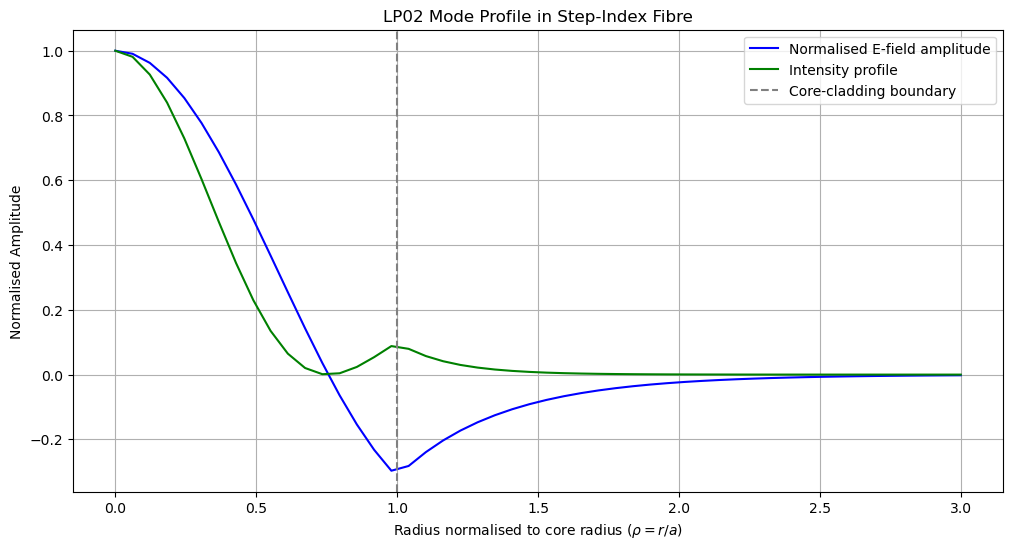

In [67]:
# 1D plot of the LP02 mode
plt.figure(figsize=(12, 6))
plt.plot(rho_02_1d, E_lp02_1d_norm, label='Normalised E-field amplitude', color='blue')
plt.plot(rho_02_1d, I_lp02_1d, label='Intensity profile', color='green')
plt.axvline(1, color='gray', linestyle='--', label='Core-cladding boundary')
plt.title('LP02 Mode Profile in Step-Index Fibre')
plt.xlabel('Radius normalised to core radius ($\\rho = r/a$)')
plt.ylabel('Normalised Amplitude')
plt.legend()
plt.grid()
plt.show()

In [68]:
# 2D grid for the LP02 mode
n = 2000 # Number of points in each dimension
x_lp02 = np.linspace(-3, 3, n) * a # from -3a to 3a
y_lp02 = np.linspace(-3, 3, n) * a
X_grid_lp02, Y_grid_lp02 = np.meshgrid(x_lp02, y_lp02)
rho_2d_lp02 = np.sqrt(X_grid_lp02**2 + Y_grid_lp02**2) / a

# Electric field as a functino of radius at rho<1 and rho>1
E_2d_lp02 = np.zeros_like(rho_2d_lp02)
core_lp02 = rho_2d_lp02 <= 1
cladding_lp02 = rho_2d_lp02 > 1

# Field in core
E_2d_lp02[core_lp02] = jv(0, X_root_lp02 * rho_2d_lp02[core_lp02])
# Matching factor for continuity at r=a
C_lp02 = jv(0, X_root_lp02) / kv(0, Y_root_lp02)
# Field in cladding
E_2d_lp02[cladding_lp02] = C_lp02 * kv(0, Y_root_lp02 * rho_2d_lp02[cladding_lp02])

# Normalise E for plotting
E_2d_lp02_norm = E_2d_lp02 / np.max(np.abs(E_2d_lp02))
I_2d_lp02 = np.abs(E_2d_lp02_norm)**2

In [69]:
I_2d_lp02.shape

(2000, 2000)

In [70]:
X_grid_lp02.shape

(2000, 2000)

In [71]:
a_lp02

9.310564170875877e-06

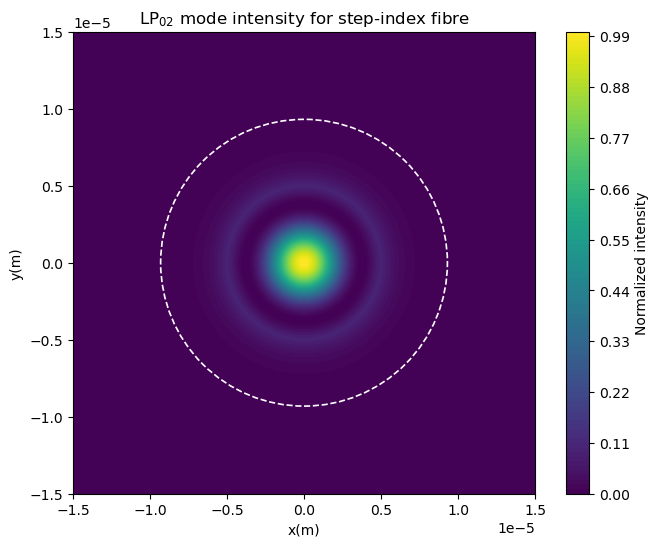

In [72]:
plt.figure(figsize=(8,6))
plt.contourf(X_grid_lp02, Y_grid_lp02, I_2d_lp02, levels=100, cmap='viridis')
plt.colorbar(label='Normalized intensity')
plt.gca().add_patch(plt.Circle((0, 0), a_lp02, color="white", fill=False, linestyle="--", linewidth=1.2))
plt.xlabel("x(m)")
plt.ylabel("y(m)")
plt.title(r"LP$_{02}$ mode intensity for step-index fibre")
plt.gca().set_aspect('equal')
plt.show()

In [73]:
# # 2D grid in radius normalized coordinates
# n = 600
# x = np.linspace(-3, 3, n)
# y = np.linspace(-3, 3, n)
# Xg, Yg = np.meshgrid(x, y)
# rho = np.sqrt(Xg**2 + Yg**2)

# # Piecewise field
# E = np.zeros_like(rho)
# core = rho <= 1
# clad = rho > 1

# E[core] = jv(0, X_root * rho[core])
# C = jv(0, X_root) / kv(0, Y_root)
# E[clad] = C * kv(0, Y_root * rho[clad])

# # Normalize for plotting
# E /= np.max(np.abs(E))
# I = np.abs(E)**2

# # 2D intensity
# plt.figure(figsize=(7, 6))
# plt.contourf(Xg, Yg, I, levels=60, cmap="viridis")
# plt.colorbar(label="Normalized intensity")
# plt.gca().add_patch(plt.Circle((0, 0), 1, color="white", fill=False, linestyle="--", linewidth=1.2))
# plt.xlabel(r"Normalized x-coordinate $x/a$")
# plt.ylabel(r"Normalized y-coordinate $y/a$")
# plt.title(r"LP$_{02}$-like ring mode intensity ($l=0,m=2$)")
# plt.gca().set_aspect("equal")
# plt.show()


### 3+ modes

In [74]:
# M=3
V_m3 = np.sqrt(4*3)
a_m3 = V_m3 * lam0 / (2 * np.pi * NA)

print(f"To support M=3 modes, the core radius a needs to be at least {a_m3*1e6:.2f} microns")
print(f"Corresponding V-number for M=3 modes: {V_m3:.2f}" )

To support M=3 modes, the core radius a needs to be at least 8.27 microns
Corresponding V-number for M=3 modes: 3.46


In [ ]:
# Define the range of x values for plotting the Bessel functions
X_m3 = np.linspace(0, V_m3, 1000)
Y_m3 = np.sqrt((V_m3)**2 - X_m3**2)

# Note: jv(v, z) represent first kind of Bessel function of order v and argument z is the input value, z = X * r / a 
LHS_m3 = X_m3 * jv(1, X_m3) / jv(0, X_m3)
RHS_m3 = Y_m3 * kv(1, Y_m3) / kv(0, Y_m3)
RHS_m3_minus = - Y_m3 * kv(1, Y_m3) / kv(0, Y_m3)

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2214220269.py:7: RuntimeWarning: invalid value encountered in multiply
  RHS_m3 = Y_m3 * kv(1, Y_m3) / kv(0, Y_m3)
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2214220269.py:8: RuntimeWarning: invalid value encountered in multiply
  RHS_m3_minus = - Y_m3 * kv(1, Y_m3) / kv(0, Y_m3)


<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2444012400.py:3: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X_m3, LHS_m3, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')


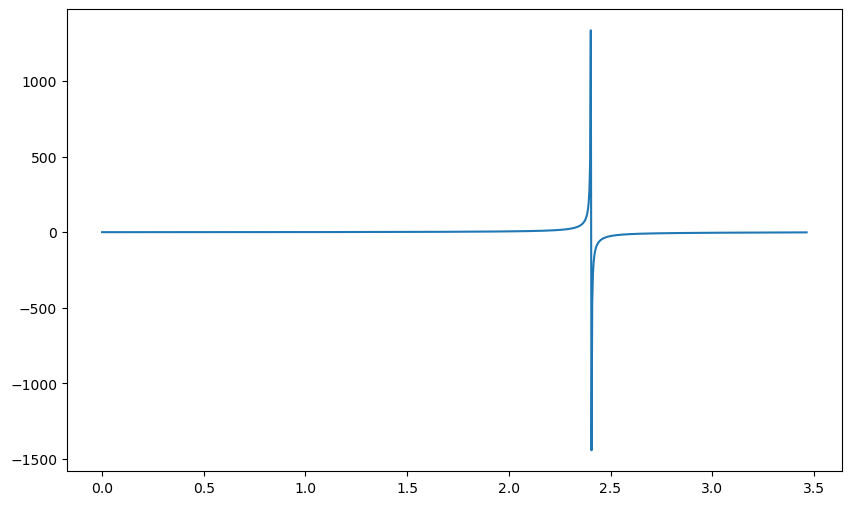

In [ ]:
# Plot the left-hand side and right-hand side of the equation
plt.figure(figsize=(10, 6))
plt.plot(X_m3, LHS_m3, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')

<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/3276501132.py:3: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X_m3, LHS_m3, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/3276501132.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m3, RHS_m3, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/3276501132.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m3, RHS_m3_minus, label='RHS: $-\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='ora

(-20.0, 20.0)

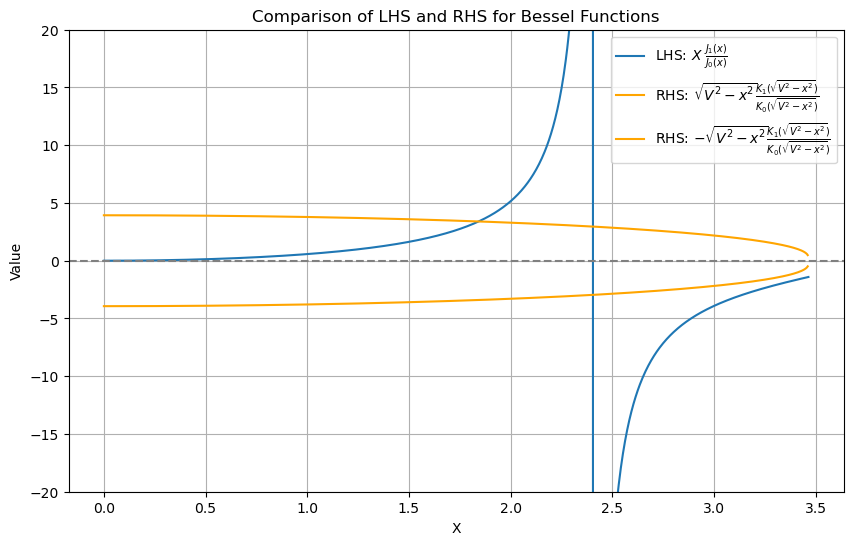

In [ ]:
# Plot the left-hand side and right-hand side of the equation
plt.figure(figsize=(10, 6))
plt.plot(X_m3, LHS_m3, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X_m3, RHS_m3, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
plt.plot(X_m3, RHS_m3_minus, label='RHS: $-\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions')
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.ylim(-20,20)

In [ ]:
# Maybe we should make the core radius bigger because I can see that the LHS and RHS do not intersect for M=3, which means the fibre cannot support M=3 modes.
M3_extra = 3.9
V_m3_extra = np.sqrt(4*M3_extra)
a_m3_extra = V_m3_extra * lam0 / (2 * np.pi * NA)
print(f"To support M=3 modes, the core radius a needs to be at least {a_m3_extra*1e6:.2f} microns")

To support M=3 modes, the core radius a needs to be at least 9.43 microns


In [ ]:
X_m3_extra = np.linspace(0, V_m3_extra, 1000)
Y_m3_extra = np.sqrt((V_m3_extra)**2 - X_m3_extra**2)
LHS_m3_extra = X_m3_extra * jv(1, X_m3_extra) / jv(0, X_m3_extra)
RHS_m3_extra = Y_m3_extra * kv(1, Y_m3_extra) / kv(0, Y_m3_extra)

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/3109704969.py:4: RuntimeWarning: invalid value encountered in multiply
  RHS_m3_extra = Y_m3_extra * kv(1, Y_m3_extra) / kv(0, Y_m3_extra)


<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/4254947016.py:2: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X_m3_extra, LHS_m3_extra, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/4254947016.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m3_extra, RHS_m3_extra, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')


(-10.0, 20.0)

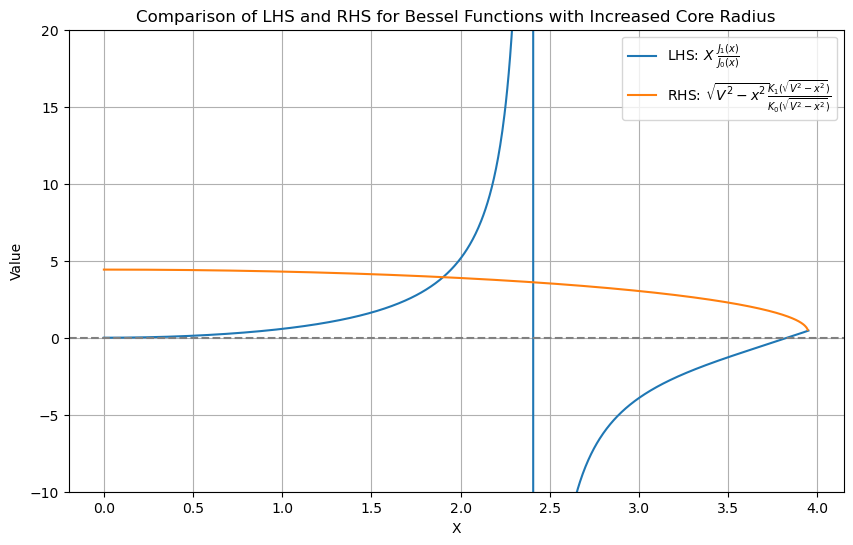

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(X_m3_extra, LHS_m3_extra, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X_m3_extra, RHS_m3_extra, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions with Increased Core Radius')
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.ylim(-10,20)

In [ ]:
M4 = 4
M5 = 5
V_m4 = np.sqrt(4*M4)
V_m5 = np.sqrt(4*M5)
a_m4 = V_m4 * lam0 / (2 * np.pi * NA)
a_m5 = V_m5 * lam0 / (2 * np.pi * NA)
print(f"Corresponding V-number for M=4 modes: {V_m4:.2f}" )
print(f"Corresponding V-number for M=5 modes: {V_m5:.2f}" )
print(f"To support M=4 modes, the core radius a needs to be at least {a_m4*1e6:.2f} microns")
print(f"To support M=5 modes, the core radius a needs to be at least {a_m5*1e6:.2f} microns")

Corresponding V-number for M=4 modes: 4.00
Corresponding V-number for M=5 modes: 4.47
To support M=4 modes, the core radius a needs to be at least 9.55 microns
To support M=5 modes, the core radius a needs to be at least 10.68 microns


In [ ]:
X_m4 = np.linspace(0, V_m4, 1000)
Y_m4 = np.sqrt((V_m4)**2 - X_m4**2)
LHS_m4 = X_m4 * jv(1, X_m4) / jv(0, X_m4)
RHS_m4 = Y_m4 * kv(1, Y_m4) / kv(0, Y_m4)
RHS_m4_minus = - Y_m4 * kv(1, Y_m4) / kv(0, Y_m4)

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2361706275.py:4: RuntimeWarning: invalid value encountered in multiply
  RHS_m4 = Y_m4 * kv(1, Y_m4) / kv(0, Y_m4)
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2361706275.py:5: RuntimeWarning: invalid value encountered in multiply
  RHS_m4_minus = - Y_m4 * kv(1, Y_m4) / kv(0, Y_m4)


In [ ]:
X_m5 = np.linspace(0, V_m5, 1000)
Y_m5 = np.sqrt((V_m5)**2 - X_m5**2)
LHS_m5 = X_m5 * jv(1, X_m5) / jv(0, X_m5)
RHS_m5 = Y_m5 * kv(1, Y_m5) / kv(0, Y_m5)
RHS_m5_minus = - Y_m5 * kv(1, Y_m5) / kv(0, Y_m5)

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2740665807.py:4: RuntimeWarning: invalid value encountered in multiply
  RHS_m5 = Y_m5 * kv(1, Y_m5) / kv(0, Y_m5)
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2740665807.py:5: RuntimeWarning: invalid value encountered in multiply
  RHS_m5_minus = - Y_m5 * kv(1, Y_m5) / kv(0, Y_m5)


<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/3222648324.py:2: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X_m4, LHS_m4, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/3222648324.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m4, RHS_m4, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/3222648324.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m4, RHS_m4_minus, label='RHS: $-\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='ora

(-10.0, 20.0)

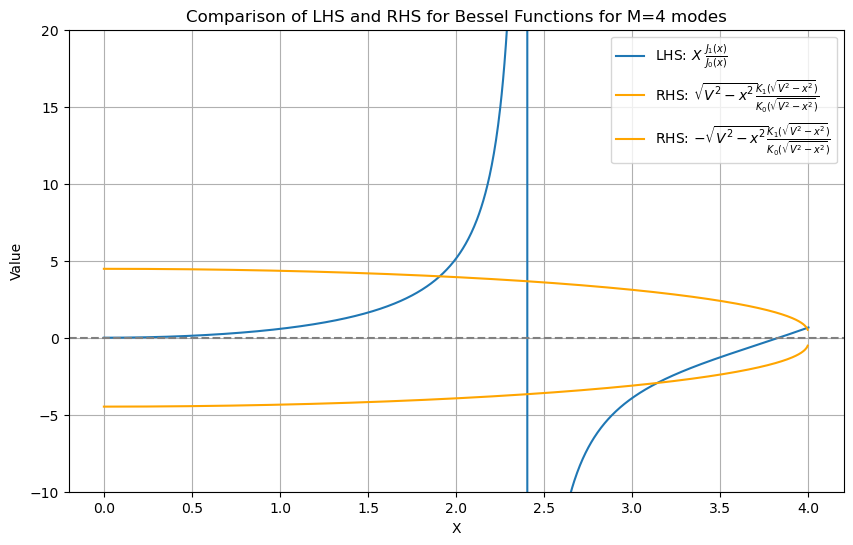

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(X_m4, LHS_m4, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X_m4, RHS_m4, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
plt.plot(X_m4, RHS_m4_minus, label='RHS: $-\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions for M=4 modes')
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.ylim(-10,20)

<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2887822993.py:2: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X_m5, LHS_m5, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2887822993.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m5, RHS_m5, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2887822993.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m5, RHS_m5_minus, label='RHS: $-\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='ora

(-10.0, 20.0)

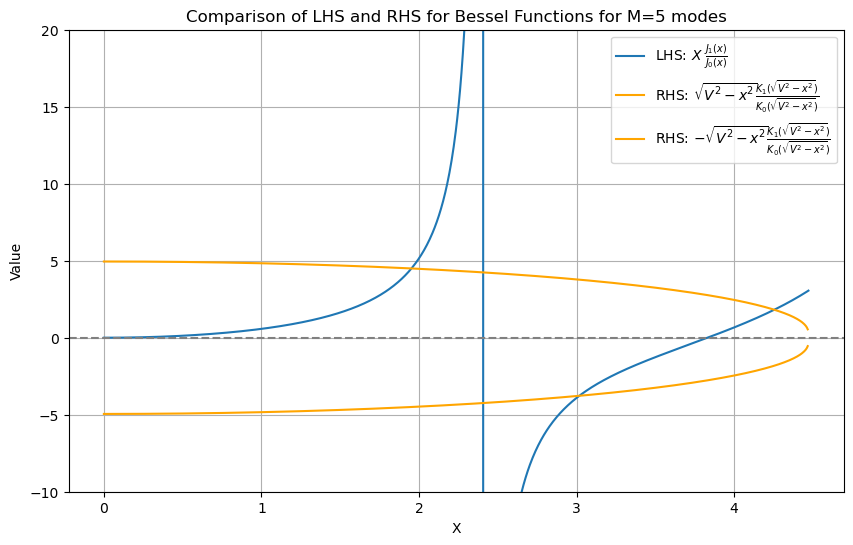

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(X_m5, LHS_m5, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X_m5, RHS_m5, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
plt.plot(X_m5, RHS_m5_minus, label='RHS: $-\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions for M=5 modes')
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.ylim(-10,20)

In [ ]:
M10=10
V_m10 = np.sqrt(4*M10)
a_m10 = V_m10 * lam0 / (2 * np.pi * NA)
print(f"Corresponding V-number for M=10 modes: {V_m10:.2f}" )
print(f"To support M=10 modes, the core radius a needs to be at least {a_m10*1e6:.2f} microns")

Corresponding V-number for M=10 modes: 6.32
To support M=10 modes, the core radius a needs to be at least 15.10 microns


In [ ]:
X_m10 = np.linspace(0, V_m10, 1000)
Y_m10 = np.sqrt((V_m10)**2 - X_m10**2)
LHS_m10 = X_m10 * jv(1, X_m10) / jv(0, X_m10)
RHS_m10 = Y_m10 * kv(1, Y_m10) / kv(0, Y_m10)
RHS_m10_minus = - Y_m10 * kv(1, Y_m10) / kv(0, Y_m10)

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2629513744.py:4: RuntimeWarning: invalid value encountered in multiply
  RHS_m10 = Y_m10 * kv(1, Y_m10) / kv(0, Y_m10)
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2629513744.py:5: RuntimeWarning: invalid value encountered in multiply
  RHS_m10_minus = - Y_m10 * kv(1, Y_m10) / kv(0, Y_m10)


<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2767424827.py:2: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X_m10, LHS_m10, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2767424827.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m10, RHS_m10, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_30073/2767424827.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_m10, RHS_m10_minus, label='RHS: $-\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', colo

(-10.0, 20.0)

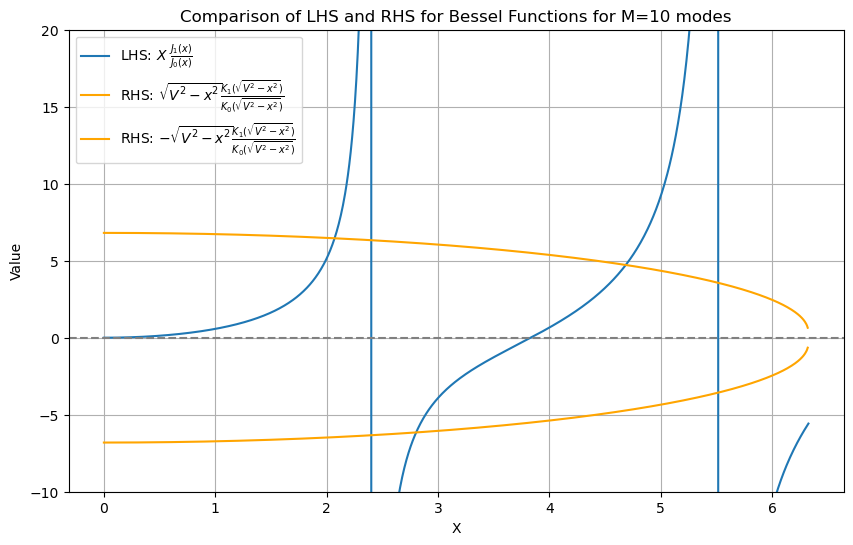

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(X_m10, LHS_m10, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X_m10, RHS_m10, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
plt.plot(X_m10, RHS_m10_minus, label='RHS: $-\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions for M=10 modes')
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.ylim(-10,20)